# Library Load

In [40]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import haversine_distances
import pickle
import os
from sklearn.preprocessing import MinMaxScaler
import lightgbm as lgb
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error
from scipy.signal import argrelextrema
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
from scipy.stats import fisk, norm
from lightgbm import LGBMRegressor
import random
import seaborn as sns
import optuna
import shap

# Functions

In [7]:
def add_cyclic_time_features(df, date_col="datetime"):
    """
    df[date_col]에 있는 날짜 정보를 기반으로
    월, 일, 시간(hour)을 sin/cos으로 변환하여 새로운 컬럼 추가
    """
    df = df.copy()
    dt = pd.to_datetime(df[date_col])
    # 계절을 구하는 함수
    def get_season(dt):
        month = dt.month
        if month in [3, 4, 5,6]:
            return 'spring'
        elif month in [7, 8,9]:
            return 'summer'
        elif month in [10, 11]:
            return 'fall'
        else:  # 12, 1, 2
            return 'winter'
    ## --- 월(Month) ---
    df["month_sin"] = np.sin(2 * np.pi * dt.dt.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * dt.dt.month / 12)

    # --- 일(Day of month) ---
    df["day_sin"] = np.sin(2 * np.pi * dt.dt.day / 31)  # 1~31
    df["day_cos"] = np.cos(2 * np.pi * dt.dt.day / 31)

    days_in_year = 365
    df['day_of_year_sin'] = np.sin(2*np.pi*dt.dt.day_of_year/days_in_year)
    df['day_of_year_cos'] = np.cos(2*np.pi*dt.dt.day_of_year/days_in_year)

    # --- 요일(Day of week) ---
    df["weekday_sin"] = np.sin(2 * np.pi * dt.dt.weekday / 7)  # 0=월요일, 6=일요일
    df["weekday_cos"] = np.cos(2 * np.pi * dt.dt.weekday / 7)
    df['Quarter'] = pd.DatetimeIndex(dt).quarter
    df['Quarter_ver2'] =(df['Quarter'] + (dt.dt.year - dt.dt.year.min()) * 4)
    if 'Quarter' in df.columns:
        if 'Quarter_Dummy' not in ['_'.join(col.split('_')[:2]) for col in df.columns]:
            df = pd.concat([df, pd.get_dummies(df['Quarter'],
                                                 prefix='Quarter_Dummy', drop_first=True)], axis=1)
            del df['Quarter']
    # --- 시간(Hour) ---
    df["hour_sin"] = np.sin(2 * np.pi * dt.dt.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * dt.dt.hour / 24)
    # 새로운 컬럼 추가
    df["season"] = df[date_col].apply(get_season)
    # 계절을 주기적으로 인코딩
    df = pd.concat([df, pd.get_dummies(df['season'],prefix='season_Dummy', drop_first=True)], axis=1)
    df=df.drop(['season'],axis=1)
    df['Quarter_Dummy_2']=df['Quarter_Dummy_2'].astype(int)
    df['Quarter_Dummy_3']=df['Quarter_Dummy_3'].astype(int)
    df['Quarter_Dummy_4']=df['Quarter_Dummy_4'].astype(int)
    df['season_Dummy_spring']=df['season_Dummy_spring'].astype(int)
    df['season_Dummy_summer']=df['season_Dummy_summer'].astype(int)
    df['season_Dummy_winter']=df['season_Dummy_winter'].astype(int)

    return df

In [10]:
def pet_hargreaves_hourly(tmin, tmax, lat, doy):
    """
    Hargreaves 공식 기반 시간단위 PET 계산 (mm/hour)
    tmin, tmax : °C
    lat : 위도 (degree)
    doy : 일자 (1~365)
    """
    phi = np.deg2rad(lat)

    # 외기권 일사량 계산 (Ra, MJ/m²/day)
    dr = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)
    delta = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)
    ws = np.arccos(-np.tan(phi) * np.tan(delta))
    Ra = (24 * 60 / np.pi) * 0.0820 * dr * (ws * np.sin(phi) * np.sin(delta) + np.cos(phi) * np.cos(delta) * np.sin(ws))

    # 평균기온
    Tmean = (tmax + tmin) / 2

    # Hargreaves 식 (mm/day)
    PET_daily = 0.0023 * (Tmean + 17.8) * np.sqrt(tmax - tmin) * Ra

    # 시간 단위 변환
    PET_hourly = PET_daily / 24
    return PET_hourly

In [11]:
def nrcs_cn_qf_hourly(P, CN):
    """hourly rainfall P(mm/h)과 CN으로 유출량/침투량 계산"""
    S = 25400.0 / CN - 254.0
    Ia = 0.2 * S
    Q = np.zeros_like(P)
    mask = P > Ia / 24.0  # 시간단위 보정
    Pm = P[mask]
    Q[mask] = ((Pm - Ia / 24.0) ** 2) / (Pm - Ia / 24.0 + S)
    F = P - Q
    return F, Q

In [12]:
def spei_hourly(P, PET, window=24):
    """
    24시간 누적 SPEI 계산 (log-logistic 근사)
    입력: P, PET → 시간별 강수량(mm/h), 잠재증발산량(mm/h)
    출력: SPEI 시계열 (원래 index 유지)
    """
    # 1️⃣ 수분수지 계산
    D = (P - PET).rolling(window=window, min_periods=window).sum()

    # 2️⃣ 유효 데이터 추출
    valid = D.dropna()
    vals = valid.values
    if len(vals) < 10:
        raise ValueError("유효 데이터가 너무 적습니다. SPEI 계산 불가.")

    # 3️⃣ 로그로지스틱 분포 피팅
    eps = 1e-6
    shifted = vals - vals.min() + eps
    c, loc, scale = fisk.fit(shifted, floc=0)

    # 4️⃣ CDF → Z-score
    cdf = fisk.cdf(shifted, c, loc=0, scale=scale)
    z_scores = norm.ppf(cdf)

    # 5️⃣ 원래 길이에 맞춰 index 기준으로 채우기
    spei_vals = pd.Series(np.nan, index=P.index)
    spei_vals.loc[valid.index] = z_scores

    return spei_vals

In [24]:
def smooth_drop_intervals(y, method='mean', threshold=None, interpolate=True):
    """
    y값이 급격하게 떨어진 구간을 NaN 처리 후 평활화하는 함수.

    Parameters
    ----------
    y : pd.Series or np.ndarray
        입력 시계열 데이터
    method : {'mean', 'std', 'threshold'}, default='mean'
        급락 기준 계산 방식
        - 'mean': diff < diff.mean()
        - 'std': diff < diff.mean() - diff.std()
        - 'threshold': diff < -abs(threshold)
    threshold : float, optional
        method='threshold'일 때 수동 기준값 (예: -3)
    interpolate : bool, default=True
        True면 NaN 구간을 선형보간으로 평활화

    Returns
    -------
    y_smooth : pd.Series
        평활화된 시계열
    nan_mask : np.ndarray (bool)
        NaN으로 처리된 구간 마스크
    """
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    # 1️⃣ 변화량 계산
    diff = y.diff()

    # 2️⃣ 급락 구간 판단 기준 설정
    if method == 'mean':
        drop_points = diff < diff.mean()
    elif method == 'std':
        drop_points = diff < (diff.mean() - diff.std())
    elif method == 'threshold' and threshold is not None:
        drop_points = diff < -abs(threshold)
    else:
        raise ValueError("method must be 'mean', 'std', or 'threshold' (with threshold value)")

    # 3️⃣ 급락 시작~종료 구간 탐색
    nan_mask = np.zeros(len(y), dtype=bool)
    i = 0
    while i < len(y):
        if drop_points.iloc[i]:
            start = i
            j = i + 1
            while j < len(y) and diff.iloc[j] <= 0:
                j += 1
            end = j
            nan_mask[start:end+1] = True
            i = end
        else:
            i += 1

    # 4️⃣ NaN 처리 및 보간
    y_smooth = y.copy()
    y_smooth[nan_mask] = np.nan
    if interpolate:
        y_smooth = y_smooth.interpolate(limit_direction='both')

    return y_smooth

In [28]:
def nse(obs, sim):
    obs = np.array(obs).reshape(-1)
    sim = np.array(sim).reshape(-1)
    return 1 - np.sum((sim - obs) ** 2) / np.sum((obs - np.mean(obs)) ** 2)

def kge(obs, sim):
    obs = np.array(obs).reshape(-1)
    sim = np.array(sim).reshape(-1)
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

# Data Import

In [3]:
adj = pd.read_csv('/content/drive/MyDrive/지하수예측경진대회/12개_지하수_지점_정보.csv')
train = pd.read_csv('/content/drive/MyDrive/지하수예측경진대회/2014_2020_시계열_지하수_기상_train.csv',encoding='cp949')
test= pd.read_csv('/content/drive/MyDrive/지하수예측경진대회/2021_2023_시계열_지하수_기상_test_inputs.csv',encoding='cp949')
export=pd.read_csv('/content/drive/MyDrive/지하수예측경진대회/근처하천수위.csv',encoding='cp949')

In [4]:
adj['CN']=[91,78,78,75,78,78,92,78,78,75,78,78] #CN값 넣어줌

# Missing Data Imputation

In [5]:
train["ymd"] = pd.to_datetime(train["ymd"])

# 전체 기간 (예: 2020년 1년치, 시간 단위)
full_range = pd.date_range("2014-01-01 00:00:00", "2020-12-31 23:00:00", freq="H")

# 결과 저장용 리스트
dfs = []

# code별 그룹 처리
for code, group in train.groupby("code_new"):
    # datetime을 인덱스로
    group = group.set_index("ymd")

    # full_range로 재인덱싱 (빠진 시간 보완)
    group = group.reindex(full_range)

    # 이전값으로 결측 채우기
    group = group.interpolate(method='time')

    # code 컬럼 복원
    group["code_new"] = code

    dfs.append(group)

# concat으로 합치기
result = pd.concat(dfs).reset_index().rename(columns={"index": "ymd"})

/tmp/ipython-input-3931252286.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range("2014-01-01 00:00:00", "2020-12-31 23:00:00", freq="H")


In [6]:
test["ymd"] = pd.to_datetime(test["ymd"])

# 전체 기간 (예: 2020년 1년치, 시간 단위)
full_range = pd.date_range("2021-01-01 00:00:00", "2023-12-31 23:00:00", freq="H")

# 결과 저장용 리스트
dfs = []

# code별 그룹 처리
for code, group in test.groupby("code_new"):
    # datetime을 인덱스로
    group = group.set_index("ymd")

    # full_range로 재인덱싱 (빠진 시간 보완)
    group = group.reindex(full_range)

    # 이전값으로 결측 채우기
    group = group.interpolate(method='time')

    # code 컬럼 복원
    group["code_new"] = code

    dfs.append(group)

# concat으로 합치기
result2 = pd.concat(dfs).reset_index().rename(columns={"index": "ymd"})

/tmp/ipython-input-1573497118.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range("2021-01-01 00:00:00", "2023-12-31 23:00:00", freq="H")


# Creating Varaibles

In [8]:
df=result.copy()
df2=result2.copy()

In [9]:
df4=pd.concat([df,df2],axis=0)

In [13]:
bb=pd.DataFrame()
horizon=1
for node in tqdm(range(12)):
    aa=df4[df4['code_new']==node+1]
    aa['y'] = aa['elev'].shift(-horizon)
    aa["ymd"] = pd.to_datetime(aa["ymd"])
    aa["date"] = aa["ymd"].dt.date
    daily_stats = aa.groupby("date")["기온(°C)"].agg(tmin="min", tmax="max").reset_index()
    lat = adj['위도'][node] # 위도
    daily_stats["doy"] = pd.to_datetime(daily_stats["date"]).dt.dayofyear
    daily_stats["pet_hourly"] = daily_stats.apply(
        lambda row: pet_hargreaves_hourly(row["tmin"], row["tmax"], lat, row["doy"]),
        axis=1
    )
    aa = aa.merge(daily_stats[["date", "pet_hourly"]], on="date", how="left")
    aa.drop('date',axis=1,inplace=True)
    aa["infiltration(mm/h)"], aa["runoff(mm/h)"] = nrcs_cn_qf_hourly(aa["강수량(mm)"], adj["CN"][node])
    aa["spei_24h"] = spei_hourly(aa["강수량(mm)"], aa["pet_hourly"], window=24)
    aa["water_balance(mm/h)"] = aa["강수량(mm)"] - aa["pet_hourly"]
    aa["infiltration_rate(%)"] = aa["infiltration(mm/h)"] / (aa["강수량(mm)"] + 1e-6) * 100
    aa["runoff_rate(%)"] = aa["runoff(mm/h)"] / (aa["강수량(mm)"] + 1e-6) * 100
    aa['cumsum_rain7d']=aa['강수량(mm)'].rolling(window=24*7, min_periods=1).sum().fillna(0)
    aa['cumsum_rain30d']=aa['강수량(mm)'].rolling(window=24*30, min_periods=1).sum().fillna(0)
    cutoff = pd.to_datetime("2019-06-01 00:01:00")
    cutoff2=pd.to_datetime("2021-01-01 00:00:00")
    # 나누기
    tr_cum = aa[aa['ymd'] < cutoff][['강수량(mm)']].cumsum()
    valid_cum = aa[(aa['ymd'] < cutoff2)&(aa['ymd'] >= cutoff)]['강수량(mm)'].cumsum()
    test_cum=aa[aa['ymd'] >= cutoff2][['강수량(mm)']].cumsum()
    rain_all=pd.concat([tr_cum,valid_cum,test_cum],axis=0)
    aa['rain_cum']=rain_all
    aa['precip_roll_7d_ratio'] =aa['cumsum_rain7d']/ (aa['rain_cum']+ 1e-9)
    aa['precip_roll_30d_ratio'] = aa['cumsum_rain30d'] / (aa['rain_cum'] + 1e-9)
    aa['k_precip7d']=adj['수리전도도(cm/sec)'][node] *10*3600 *aa['cumsum_rain7d']
    aa['k_precip30d']=adj['수리전도도(cm/sec)'][node] *10*3600 *aa['cumsum_rain30d']
    bb=pd.concat([aa,bb],axis=0)

  0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipython-input-528787226.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aa['y'] = aa['elev'].shift(-horizon)
/tmp/ipython-input-528787226.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aa["ymd"] = pd.to_datetime(aa["ymd"])
/tmp/ipython-input-528787226.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

In [14]:
bb.columns= [
    'ymd',
    'code_new',
    'elev',
    'wtemp',
    'ec',
    'air_temp_c',          # 기온(°C)
    'precip_mm',           # 강수량(mm)
    'wind_speed_ms',       # 풍속(m/s)
    'humidity_pct',        # 습도(%)
    'pressure_hpa',        # 현지기압(hPa)
    'ground_temp_c',       # 지면온도(°C)
    'y',
    'pet_hourly',
    'infiltration_mm_h',   # 침투량(mm/h)
    'runoff_mm_h',         # 유출량(mm/h)
    'spei_24h',
    'water_balance_mm_h',  # 수분수지(mm/h)
    'infiltration_rate_pct',  # 침투율(%)
    'runoff_rate_pct',        # 유출율(%)
    'cumsum_rain7d',
    'cumsum_rain30d',
    'rain_cum',
    'precip_roll_7d_ratio',
    'precip_roll_30d_ratio',
    'k_precip7d',
    'k_precip30d'
]

# Make Polynomial Features

In [15]:
# 다항 특성 변환기 (예: 2차)
X=bb.drop(['ymd','code_new','elev','y'],axis=1).fillna(0)
poly = PolynomialFeatures(degree=2, include_bias=False,interaction_only=True)
X_poly = poly.fit_transform(X)

# 새로운 다항 특성 이름 생성
poly_features = poly.get_feature_names_out(X.columns)

# DataFrame으로 변환
X_poly_df = pd.DataFrame(X_poly, columns=poly_features, index=bb.index)

# 원래 df와 합치기
df_poly = pd.concat([bb, X_poly_df], axis=1)


In [16]:
df_no_dup = df_poly.loc[:, ~df_poly.columns.duplicated()]
df_no_dup = df_no_dup.sort_values(by=['code_new','ymd'],ascending=True)
df_no_dup['ymd']=pd.to_datetime(df_no_dup['ymd'])
export['ymd']=pd.to_datetime(export['ymd'])
df_no_dup=pd.merge(df_no_dup,export,on=['code_new','ymd'],how='left')

# 근처 하천 수위 넣어주기

In [17]:
# node별 선형보간 + 양쪽 외삽
df_no_dup['wl'] = df_no_dup.groupby('code_new')['wl'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

In [18]:
ff=pd.DataFrame()
for node in range(12):
    gg = df_no_dup[df_no_dup['code_new']==node+1]
    gg['kwl']=gg['wl']*adj['수리전도도(cm/sec)'][node] *10*3600
    ff=pd.concat([ff,gg],axis=0)

/tmp/ipython-input-3553196370.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gg['kwl']=gg['wl']*adj['수리전도도(cm/sec)'][node] *10*3600
/tmp/ipython-input-3553196370.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gg['kwl']=gg['wl']*adj['수리전도도(cm/sec)'][node] *10*3600
/tmp/ipython-input-3553196370.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

# Train Test split

In [22]:
# 기준 시점
cutoff = pd.to_datetime("2020-12-31 23:00:00")
df_no_dup2=add_cyclic_time_features(ff, date_col="ymd")

In [23]:
# 나누기
df_before = df_no_dup2[df_no_dup2['ymd'] < cutoff]
df_after  = df_no_dup2[df_no_dup2['ymd'] >= cutoff]

In [25]:
df_before=df_before.dropna(axis=0)
df_after=df_after.drop(['elev'],axis=1)

In [26]:
x=[]
y=[]
c=[]
test=[]
cutoff = pd.to_datetime("2014-01-02 00:00:00")
cutoff2 = pd.to_datetime("2021-01-01 00:00:00")
for node in range(12):
    x.append(df_before[df_before['code_new']==node+1].drop(['ymd','elev','code_new','y'],axis=1).values)
    y.append(smooth_drop_intervals(df_before[df_before['code_new']==node+1]['y'].values))
    c.append(df_no_dup2[df_no_dup2['code_new']==node+1][(df_no_dup2['ymd'] >= cutoff)&(df_no_dup2['ymd'] < cutoff2)]['elev'].values)
    test.append(df_after[df_after['code_new']==node+1].drop(['ymd','code_new','y'],axis=1).values[:-1])

/tmp/ipython-input-636161759.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  c.append(df_no_dup2[df_no_dup2['code_new']==node+1][(df_no_dup2['ymd'] >= cutoff)&(df_no_dup2['ymd'] < cutoff2)]['elev'].values)
/tmp/ipython-input-636161759.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  c.append(df_no_dup2[df_no_dup2['code_new']==node+1][(df_no_dup2['ymd'] >= cutoff)&(df_no_dup2['ymd'] < cutoff2)]['elev'].values)
/tmp/ipython-input-636161759.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  c.append(df_no_dup2[df_no_dup2['code_new']==node+1][(df_no_dup2['ymd'] >= cutoff)&(df_no_dup2['ymd'] < cutoff2)]['elev'].values)
/tmp/ipython-input-636161759.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  c.append(df_no_dup2[df_no_dup2['code_new']==node+1][(df_no_dup2['ymd'] >= cutoff)&(df_no_dup2['ymd'] < cutoff2)]['elev'].values)
/tmp/ipython-input-636161759

In [27]:
x=np.array(x).transpose(1,0,2)
test=np.array(test).transpose(1,0,2)
y=np.array(y).transpose(1,0)
c=np.array(c).transpose(1,0)

In [29]:
x_train = x[:round(len(x)*0.8)]
x_valid = x[round(len(x)*0.8):]
y_train = y[:round(len(x)*0.8)]
y_valid = y[round(len(x)*0.8):]
y_train_c = c[:round(len(x)*0.8)]
y_valid_c= c[round(len(x)*0.8):]

#

# Run!

  0%|          | 0/12 [00:00<?, ?it/s][I 2025-10-16 13:43:18,067] A new study created in memory with name: no-name-737caabc-147f-41f4-9a76-b80ed6dd36f5
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 13:43:22,943] Trial 0 finished with value: -0.7235748804795221 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.7235748804795221.
[I 2025-10-16 13:43:52,053] Trial 1 finished with value: -0.7264413920402504 and parameters: {'num_leaves': 89, 'max_depth': 10, 'learning_rate': 0.010485387725194618, 'feature_fraction': 0.9909729556485982, 'bagging_fraction': 0.9497327922401265, 'lambda_l1': 2.1233911067827616, 'lambda_l2':


Node 1 - MAE: 0.1020, NSE: 0.7918, KGE: 0.7955


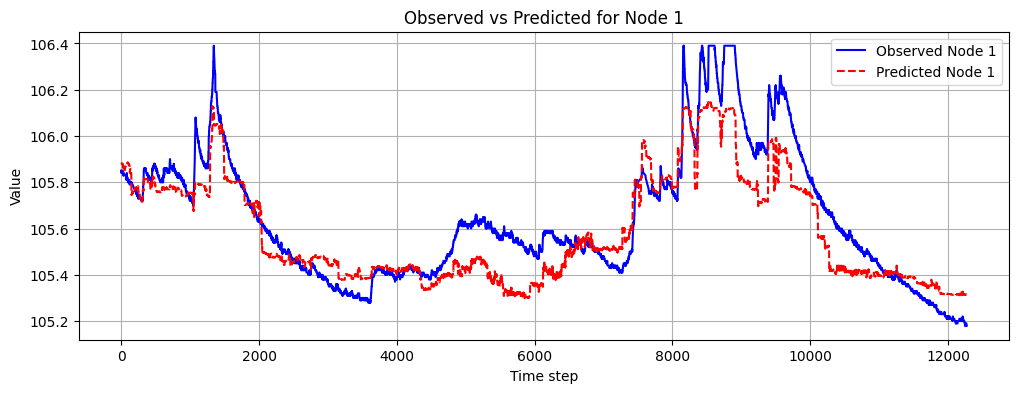

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
  8%|▊         | 1/12 [03:44<41:08, 224.44s/it][I 2025-10-16 13:47:02,498] A new study created in memory with name: no-name-2b641aca-ef53-48b4-a150-1934b57cf1ec
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 13:47:05,686] Trial 0 finished with value: -0.6068834521404585 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.6068834521404585.
[I 2025-10-16 13:47:15,742] Trial 1 finished with value: -0.6041594951562379 and parameters: {'num_leaves': 89, 'max


Node 2 - MAE: 0.2094, NSE: 0.5236, KGE: 0.7334


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


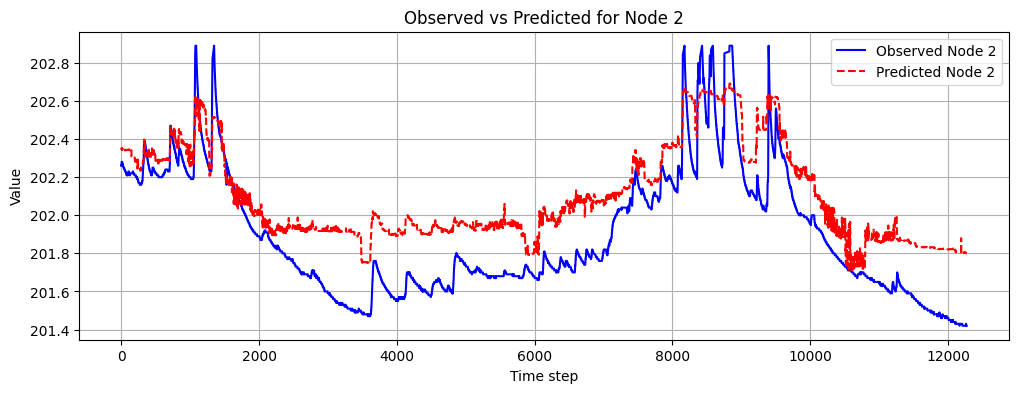

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 17%|█▋        | 2/12 [06:09<29:34, 177.47s/it][I 2025-10-16 13:49:27,091] A new study created in memory with name: no-name-5944aed2-84e5-441e-ad2f-c1d1303d8f87
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 13:49:40,943] Trial 0 finished with value: -0.883286593550493 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.883286593550493.
[I 2025-10-16 13:50:05,336] Trial 1 finished with value: -0.882901332096005 and parameters: {'num_leaves': 89, 'max_de


Node 3 - MAE: 0.1357, NSE: 0.9066, KGE: 0.9167


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


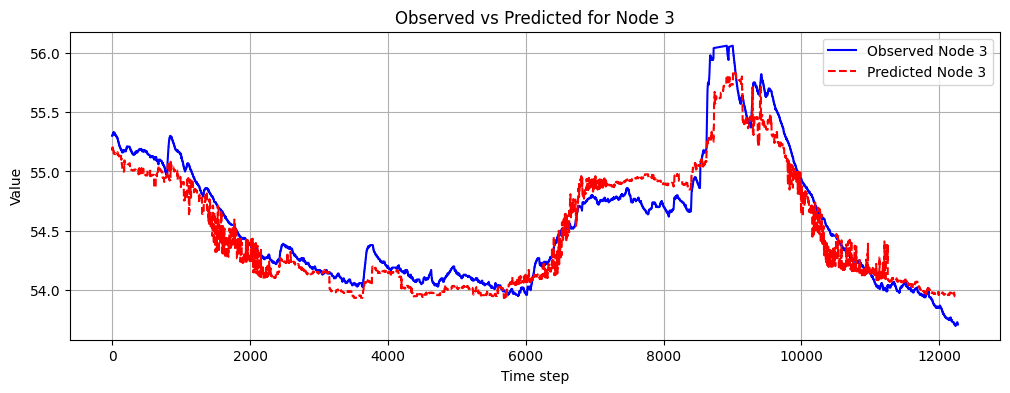

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 25%|██▌       | 3/12 [10:49<33:41, 224.57s/it][I 2025-10-16 13:54:07,713] A new study created in memory with name: no-name-6a2749d8-4cef-4284-bbb9-562ee0c848bc
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 13:54:10,701] Trial 0 finished with value: -0.6190830408219203 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.6190830408219203.
[I 2025-10-16 13:54:28,816] Trial 1 finished with value: -0.6164208435826086 and parameters: {'num_leaves': 89, 'max


Node 4 - MAE: 0.1648, NSE: 0.6326, KGE: 0.6088


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


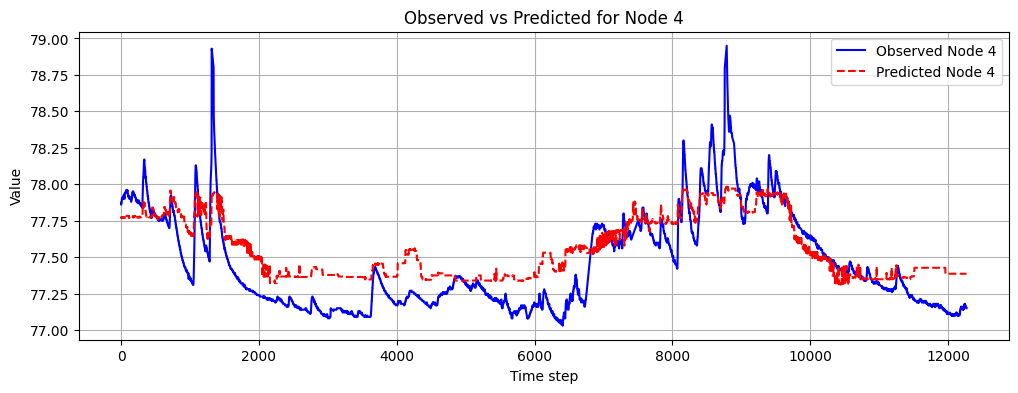

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 33%|███▎      | 4/12 [13:26<26:22, 197.78s/it][I 2025-10-16 13:56:44,407] A new study created in memory with name: no-name-058d717a-0ece-413b-a8e3-ecdba58b1839
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 13:56:48,848] Trial 0 finished with value: -0.5801113780978326 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.5801113780978326.
[I 2025-10-16 13:57:05,252] Trial 1 finished with value: -0.5499488233632075 and parameters: {'num_leaves': 89, 'max


Node 5 - MAE: 0.1856, NSE: 0.4545, KGE: 0.5395


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


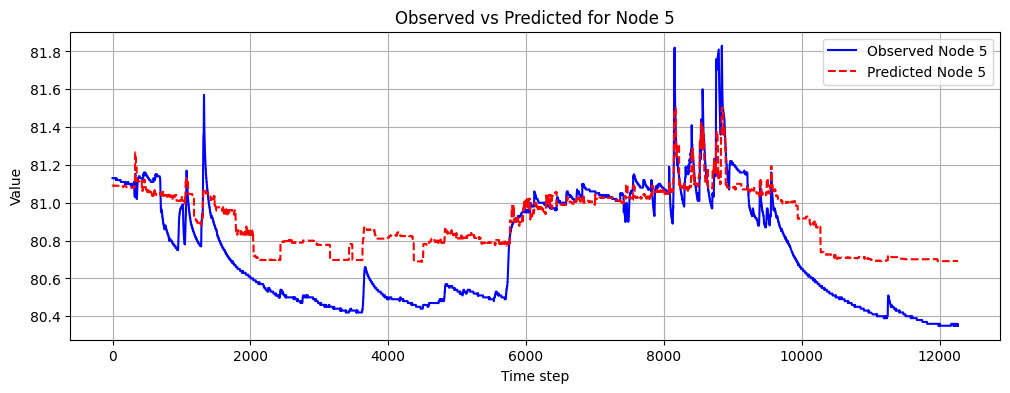

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 42%|████▏     | 5/12 [18:02<26:23, 226.15s/it][I 2025-10-16 14:01:20,860] A new study created in memory with name: no-name-2f5c8ed0-1502-489b-906e-81055ae61bd0
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 14:01:26,300] Trial 0 finished with value: -0.897574548025813 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.897574548025813.
[I 2025-10-16 14:01:34,023] Trial 1 finished with value: -0.8791099455358844 and parameters: {'num_leaves': 89, 'max_d


Node 6 - MAE: 0.0936, NSE: 0.8648, KGE: 0.9562


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


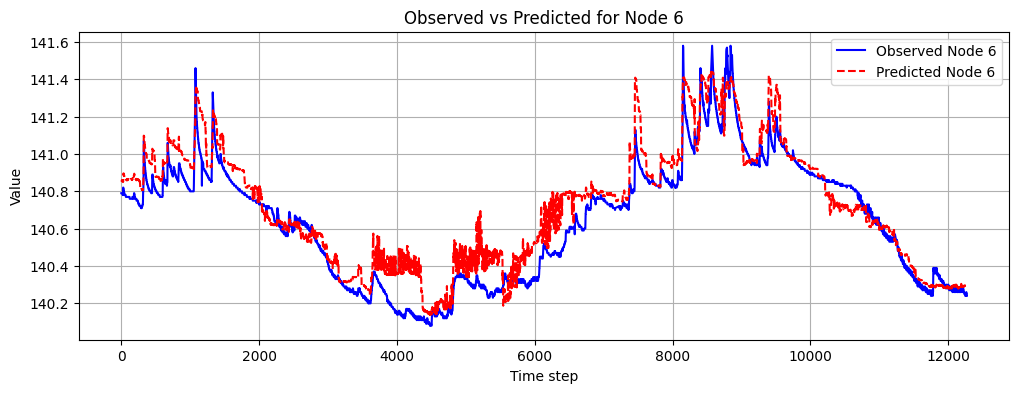

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 50%|█████     | 6/12 [20:33<20:03, 200.53s/it][I 2025-10-16 14:03:51,658] A new study created in memory with name: no-name-719a5c0a-7709-4511-94dd-22763adfd44b
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 14:03:56,724] Trial 0 finished with value: -0.6175052911662609 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.6175052911662609.
[I 2025-10-16 14:04:22,889] Trial 1 finished with value: -0.5939447999312444 and parameters: {'num_leaves': 89, 'max


Node 7 - MAE: 0.1230, NSE: 0.7051, KGE: 0.6950


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


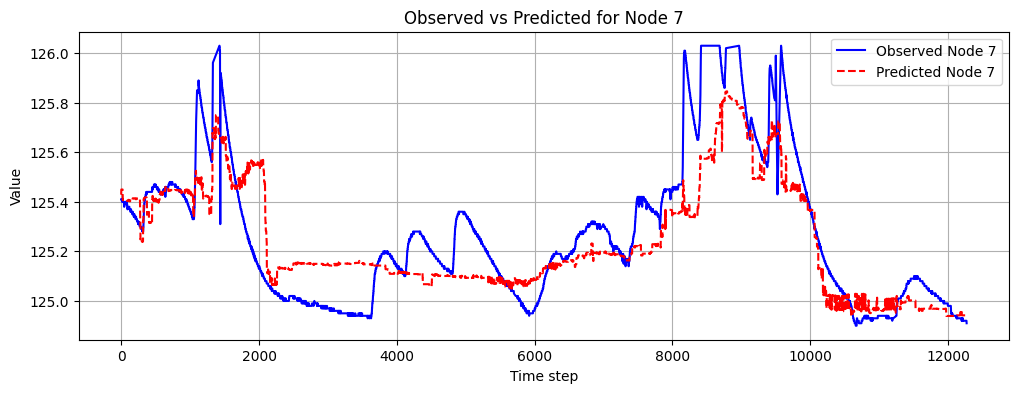

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 58%|█████▊    | 7/12 [26:04<20:15, 243.01s/it][I 2025-10-16 14:09:22,128] A new study created in memory with name: no-name-7c19ccc3-d699-4d4c-a8ab-c8c47ed36356
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 14:09:30,235] Trial 0 finished with value: -0.7463237999055004 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.7463237999055004.
[I 2025-10-16 14:09:47,349] Trial 1 finished with value: -0.6996543182710283 and parameters: {'num_leaves': 89, 'max


Node 8 - MAE: 0.1068, NSE: 0.7586, KGE: 0.8302


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


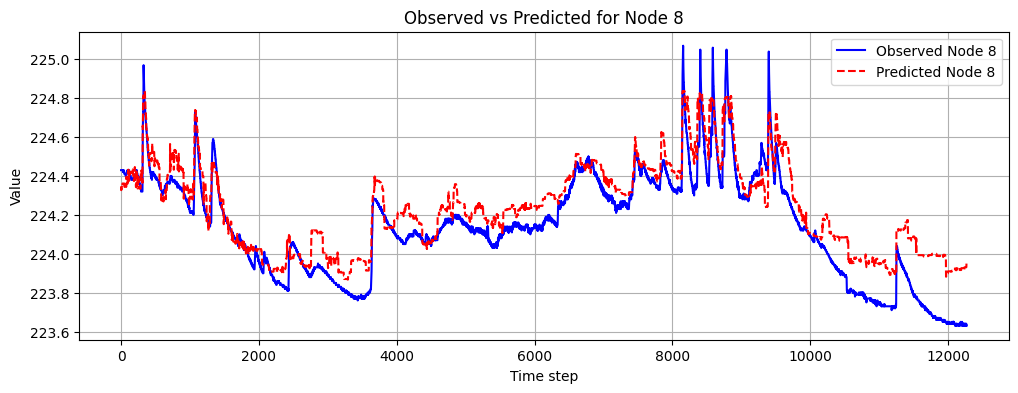

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 67%|██████▋   | 8/12 [29:15<15:06, 226.69s/it][I 2025-10-16 14:12:33,889] A new study created in memory with name: no-name-d0f97d75-096e-47f9-a6bd-9b2eb1236cc5
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 14:12:38,793] Trial 0 finished with value: -0.5646439774755059 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.5646439774755059.
[I 2025-10-16 14:13:07,210] Trial 1 finished with value: -0.5865209509651127 and parameters: {'num_leaves': 89, 'max


Node 9 - MAE: 0.0994, NSE: 0.7372, KGE: 0.7854


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


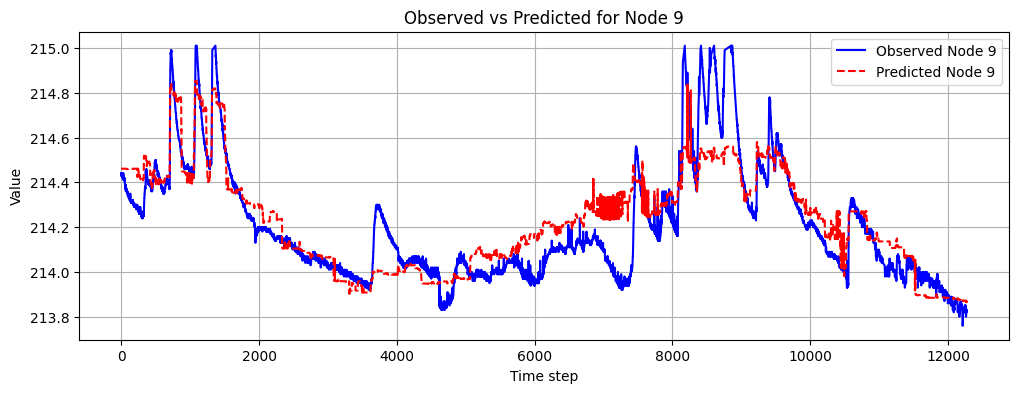

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 75%|███████▌  | 9/12 [33:42<11:57, 239.13s/it][I 2025-10-16 14:17:00,365] A new study created in memory with name: no-name-5b21571f-6656-484e-a4bf-3722abd3daf3
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 14:17:05,799] Trial 0 finished with value: 0.9528054542531028 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: 0.9528054542531028.
[I 2025-10-16 14:17:57,389] Trial 1 finished with value: 0.3930978671049219 and parameters: {'num_leaves': 89, 'max_de


Node 10 - MAE: 0.1109, NSE: -0.0993, KGE: 0.2172


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


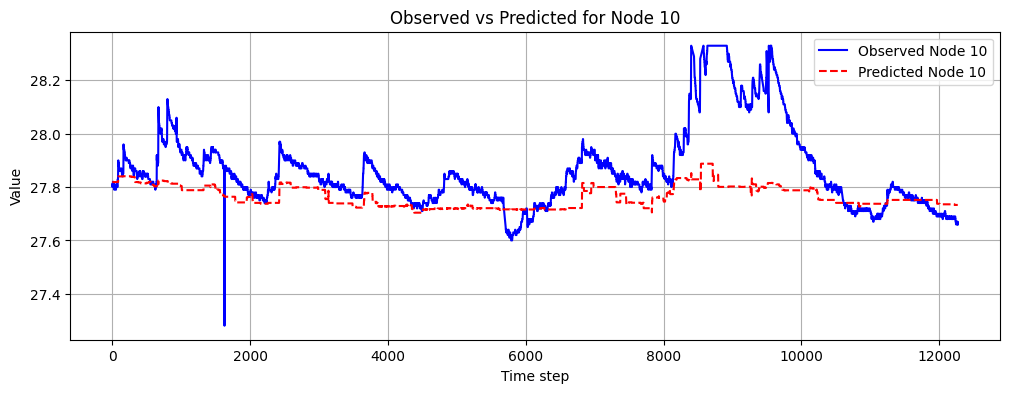

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 83%|████████▎ | 10/12 [40:04<09:26, 283.36s/it][I 2025-10-16 14:23:22,776] A new study created in memory with name: no-name-01b89cb4-f301-43b4-8ef1-62b8d67ba7b5
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 14:23:29,691] Trial 0 finished with value: -0.6744376753328127 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.6744376753328127.
[I 2025-10-16 14:23:50,920] Trial 1 finished with value: -0.6442934369822713 and parameters: {'num_leaves': 89, 'ma


Node 11 - MAE: 0.0682, NSE: 0.6321, KGE: 0.7872


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


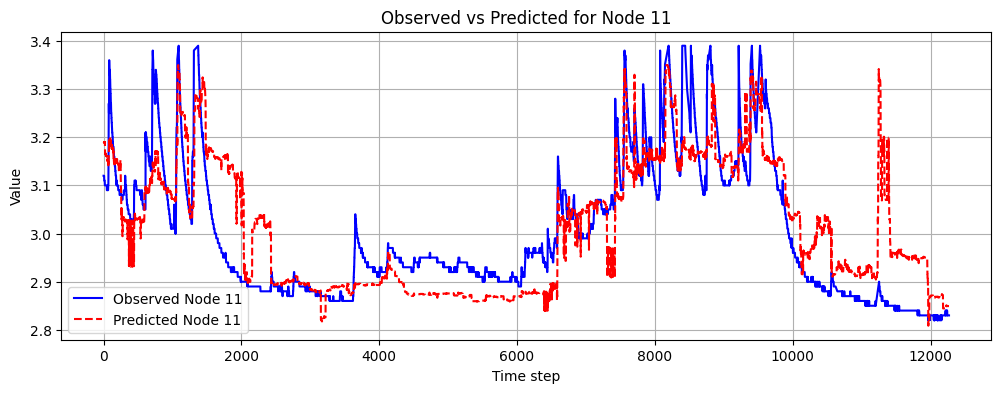

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
 92%|█████████▏| 11/12 [45:19<04:53, 293.08s/it][I 2025-10-16 14:28:37,871] A new study created in memory with name: no-name-e8285c01-04eb-44cc-9a3a-2d8b130969c2
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
[I 2025-10-16 14:28:50,332] Trial 0 finished with value: -0.7027957196345975 and parameters: {'num_leaves': 67, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'feature_fraction': 0.8795975452591109, 'bagging_fraction': 0.7468055921327309, 'lambda_l1': 1.5599452033620265, 'lambda_l2': 0.5808361216819946, 'min_data_in_leaf': 88}. Best is trial 0 with value: -0.7027957196345975.
[I 2025-10-16 14:29:17,317] Trial 1 finished with value: -0.6955327353067347 and parameters: {'num_leaves': 89, 'ma


Node 12 - MAE: 0.1081, NSE: 0.7112, KGE: 0.7310


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


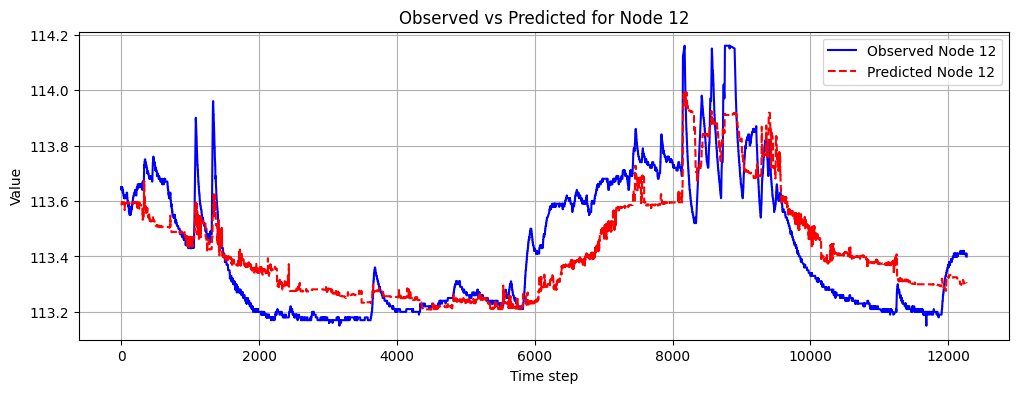

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
100%|██████████| 12/12 [48:34<00:00, 242.90s/it]


In [36]:

# ✅ 전역 시드 고정
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
optuna.seed = SEED

def nse_metric(y_pred, dataset):
    """
    LightGBM용 NSE (Nash–Sutcliffe Efficiency) 사용자 정의 metric
    """
    y_true = dataset.get_label()
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)

    if denominator == 0:
        nse_score = -np.inf
    else:
        nse_score = 1 - (numerator / denominator)

    return 'nse', nse_score, True


def objective(trial, X_train, y_train, X_valid, y_valid):
    params = {
        "objective": "regression",
        "metric": "None",  # 사용자 정의 NSE metric 사용
        "verbosity": -1,
        "boosting_type": "gbdt",
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.7, 1.0),
        "lambda_l1": trial.suggest_float("lambda_l1", 0, 10),
        "lambda_l2": trial.suggest_float("lambda_l2", 0, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "bagging_seed": SEED,
        "feature_fraction_seed": SEED,
        "random_state": SEED,
    }

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_valid = lgb.Dataset(X_valid, y_valid, reference=lgb_train)

    model = lgb.train(
        params,
        lgb_train,
        valid_sets=[lgb_valid],
        num_boost_round=2000,
        feval=nse_metric,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )

    # validation 예측
    y_pred = model.predict(X_valid, num_iteration=model.best_iteration)
    nse_val = nse(y_valid, y_pred)
    return -nse_val  # Optuna는 최소화하므로 음수 반환


# -----------------------------
# ✅ 노드별 학습 및 평가 루프
# -----------------------------
metric = []
final = []
best_params_per_node = {}
models_per_node = {}

for node in tqdm(range(0, 12)):
    pt_x = MinMaxScaler()
    pt_y = MinMaxScaler()

    x_train_re = x_train[:, node, :]
    x_valid_re = x_valid[:, node, :]
    y_train_re = y_train[:, node]
    y_valid_re = y_valid[:, node]
    x_test = test[:, node, :]

    # 스케일링
    pt_x.fit(x_train_re)
    pt_y.fit(y_train_re.reshape(-1, 1))
    x_train_re = pt_x.transform(x_train_re)
    x_valid_re = pt_x.transform(x_valid_re)
    y_train_re = pt_y.transform(y_train_re.reshape(-1, 1))
    y_valid_re = pt_y.transform(y_valid_re.reshape(-1, 1))
    x_test_re = pt_x.transform(x_test)

    # -----------------------------
    # ✅ Optuna 튜닝 (seed 고정)
    # -----------------------------
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(lambda trial: objective(trial, x_train_re, y_train_re, x_valid_re, y_valid_re),
                   n_trials=30, show_progress_bar=False)

    best_params = study.best_trial.params
    best_params.update({
        "objective": "regression",
        "metric": "None",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": SEED,
        "bagging_seed": SEED,
        "feature_fraction_seed": SEED
    })
    best_params_per_node[node] = best_params

    # -----------------------------
    # ✅ 최적 파라미터로 검증 평가
    # -----------------------------
    best_model = lgb.LGBMRegressor(
        **best_params,
        n_jobs=-1
    )
    best_model.fit(x_train_re, y_train_re.ravel())

    y_valid_pred = best_model.predict(x_valid_re)
    y_pred = pt_y.inverse_transform(y_valid_pred.reshape(-1, 1))
    y_label = pt_y.inverse_transform(y_valid_re)

    mae_val = mean_absolute_error(y_valid_c[:, node], y_pred)
    nse_val = nse(y_valid_c[:, node], y_pred)
    kge_val = kge(y_valid_c[:, node], y_pred)

    print(f"\nNode {node+1} - MAE: {mae_val:.4f}, NSE: {nse_val:.4f}, KGE: {kge_val:.4f}")
    metric.append({'MAE': mae_val, 'NSE': nse_val, 'KGE': kge_val})

    plt.figure(figsize=(12, 4))
    plt.plot(y_valid_c[:, node], label=f"Observed Node {node+1}", color='blue')
    plt.plot(y_pred, label=f"Predicted Node {node+1}", color='red', linestyle='--')
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.title(f"Observed vs Predicted for Node {node+1}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # ✅ 최적 파라미터로 전체 재학습
    # -----------------------------
    lgb_train_full = lgb.Dataset(
        np.concatenate([x_train_re, x_valid_re]),
        np.concatenate([y_train_re, y_valid_re])
    )

    model_full = lgb.train(
        best_params,
        lgb_train_full,
        num_boost_round=int(study.best_trial.number * 50) + 300
    )

    models_per_node[node] = model_full
    infer = model_full.predict(x_test_re, num_iteration=model_full.best_iteration)
    infer = pt_y.inverse_transform(infer.reshape(-1, 1))
    final.append(infer)

# Check Validation Evaluation

In [37]:
p2=pd.DataFrame(metric)
p2.loc["평균"] = p2.mean()
p2

,MAE,NSE,KGE
0,0.101975,0.791784,0.795501
1,0.209354,0.523593,0.733429
2,0.135675,0.906565,0.916680
3,0.164810,0.632577,0.608790
4,0.185635,0.454526,0.539483
5,0.093588,0.864795,0.956173
6,0.123012,0.705081,0.695025
7,0.106836,0.758593,0.830189
8,0.099413,0.737240,0.785419
9,0.110895,-0.099282,0.217165


# Feature Importance

/tmp/ipython-input-3196033260.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top20.index, x=top20.values, palette="viridis")


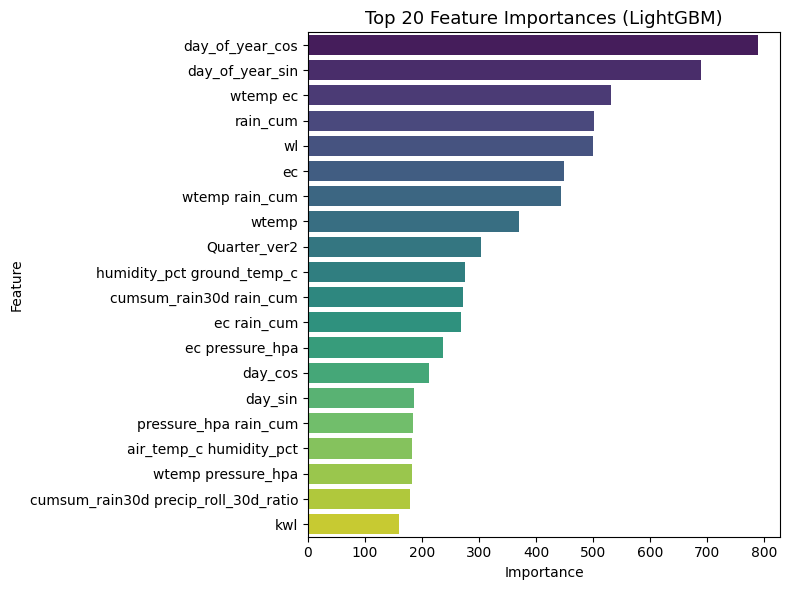

In [39]:

# 피처 이름 목록 (불필요 컬럼 제외)
cols = df_before.drop(['code_new', 'elev', 'ymd', 'y'], axis=1).columns.tolist()

# LightGBM 피처 중요도 추출
all_importances = pd.Series(model_full.feature_importance(), index=cols)

# 중요도 상위 20개 추출 (내림차순 정렬)
top20 = all_importances.sort_values(ascending=False).head(20)

# Barplot 시각화
plt.figure(figsize=(8, 6))
sns.barplot(y=top20.index, x=top20.values, palette="viridis")
plt.title("Top 20 Feature Importances (LightGBM)", fontsize=13)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Shaply Values

/tmp/ipython-input-2086099341.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_valid_re, show=False,feature_names=df_before.drop(['code_new','ymd','elev','y'],axis=1).columns)


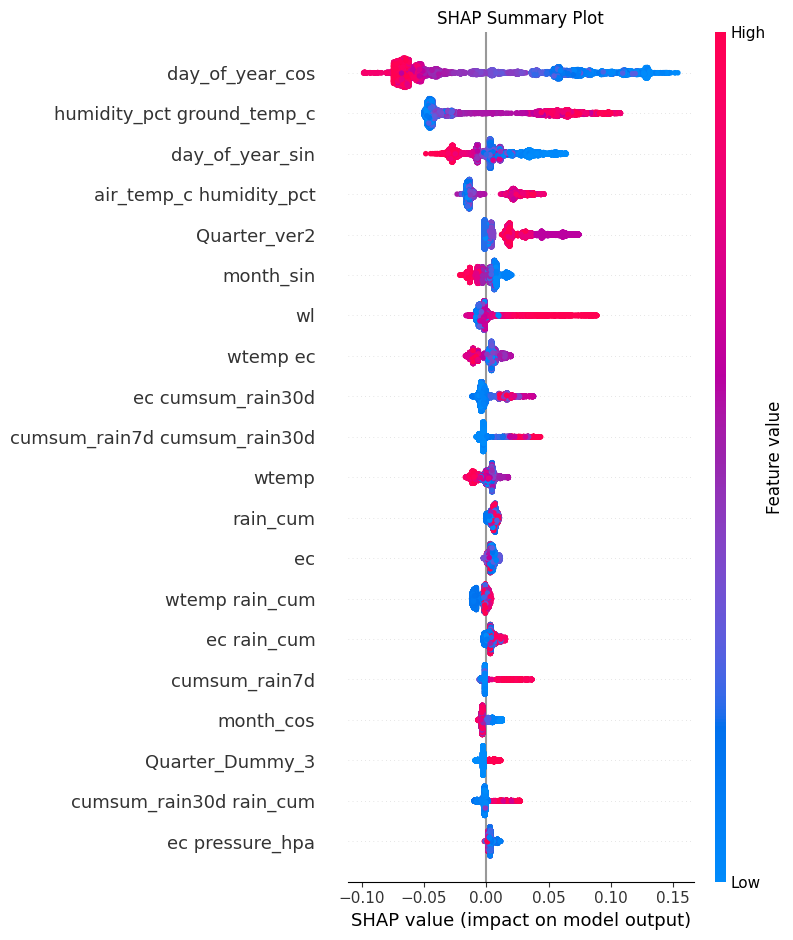

In [41]:
# -------------------------------
explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(x_valid_re)

# -------------------------------
# 4️⃣ SHAP Summary Plot (전체 feature 중요도)
# -------------------------------
plt.title("SHAP Summary Plot")
shap.summary_plot(shap_values, x_valid_re, show=False,feature_names=df_before.drop(['code_new','ymd','elev','y'],axis=1).columns)
plt.show()


# Submission

In [42]:
submission=pd.read_csv('/content/drive/MyDrive/지하수예측경진대회/2021_2023_시계열_지하수_test_sample.csv')

In [43]:
aa=pd.to_datetime(df2[df2['code_new']==1]['ymd']).values
bb=pd.to_datetime(submission['ymd']).values
diff = list(set(aa) - set(bb))

In [45]:
ff=df2[df2['code_new']==1]
ff['ymd']=pd.to_datetime(ff['ymd'])
remove_idx =ff[ff['ymd'].isin(diff)].index

/tmp/ipython-input-2263581575.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ff['ymd']=pd.to_datetime(ff['ymd'])


In [46]:
for node in range(12):
    arr=np.array(final)[node]

    submission[(f"{node+1}")]=np.delete(arr, remove_idx)

In [61]:
test=pd.read_csv('/content/drive/MyDrive/지하수예측경진대회/2021_2023_시계열_지하수_기상_test_inputs.csv',encoding='cp949')
full_time_index = pd.date_range(start=test['ymd'].min(), end=test['ymd'].max(), freq='H')
nodes = test['code_new'].unique()

# -----------------------------
# 2️⃣ 노드별로 행이 없는 곳만 0으로 채우기
# -----------------------------
dfs = []
test['elev']=1
test2=test[['ymd','code_new','elev']]
for node in nodes:
    df_node = test2[test2['code_new'] == node].copy()
    # 전체 시간 인덱스로 reindex, 기존 elev 유지, 없는 곳만 0
    df2_node=df_node.reindex(full_time_index).reset_index(drop=False)
    df2_node.columns=['ymd','ymd2','code_new','elev']
    df_node["ymd"] = pd.to_datetime(df_node["ymd"])
    df3=pd.merge(df2_node,df_node,how='left',on='ymd')
    df3['code_new'] = node
    df3['elev_y'] = df3['elev_y'].fillna(0)  # 없는 곳만 0
    dfs.append(df3)

# 병합
df_full = pd.concat(dfs)

# -----------------------------
# 3️⃣ pivot
# -----------------------------
df_pivot = df_full.pivot_table(index='ymd', columns='code_new', values='elev_y', fill_value=0)

/tmp/ipython-input-1109617613.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_time_index = pd.date_range(start=test['ymd'].min(), end=test['ymd'].max(), freq='H')


In [65]:
zero=df_pivot.reset_index(drop=False).copy()
# 1️⃣ ymd 컬럼 제외한 나머지 컬럼들
cols = [c for c in zero.columns if c != 'ymd']

# 2️⃣ 값이 0인 위치 찾기
zero_positions = (zero[cols] == 0)

# 3️⃣ (ymd, 컬럼명) 추출
zero_locs = [(zero.loc[i, 'ymd'], col) for col in cols for i in zero.index if zero_positions.loc[i, col]]


In [66]:
for y, c in zero_locs:
    submission.loc[submission['ymd'] == y, c] = np.nan

In [67]:
submission.to_csv('/content/drive/MyDrive/지하수예측경진대회/final_submission.csv',index=False)